# MFCC et FILTRAGE OUTLIERS

In [ ]:
import os
import pandas as pd
import numpy as np
import subprocess
from tqdm import tqdm
import warnings
from scipy.spatial.distance import cdist
from pathlib import Path

warnings.filterwarnings('ignore')

# DEBUT CHARGEMENT
print("Chargement des données...")
df_en = pd.read_csv("../../interspeech-2020-perceptimatic/DATA/english/all_aligned_clean_english.csv", sep=r"\s+")
df_fr = pd.read_csv("../../interspeech-2020-perceptimatic/DATA/french/all_aligned_clean_french.csv", sep=r"\s+")
df_en['language'] = 'english'
df_fr['language'] = 'french'
df_items = pd.concat([df_en, df_fr])

df_tests = pd.read_csv("../../interspeech-2020-perceptimatic/DATA/human_and_models.csv", low_memory=False)

# Construction de item_triplet 
df_tests['item_triplet'] = df_tests['language'].astype(str) + "_" + \
                            df_tests['TGT_item'].astype(str) + "_" + \
                            df_tests['OTH_item'].astype(str) + "_" + \
                            df_tests['X_item'].astype(str)

# Outliers connus, liste hardcodée
outliers_total = {34, 35, 72, 76, 77, 79, 82, 86, 92, 123, 140, 141, 159, 161, 179, 180}

# df_tests 
df_tests = df_tests[~df_tests['individual'].isin(outliers_total)].copy()

# triplets valides 
triplets_valides = set(df_tests['item_triplet'])

# df_triplets = liste des triplets uniques à calculer
df_triplets = df_tests.drop_duplicates(subset=['filename', 'language']).copy()

print(f"Outliers supprimés ({len(outliers_total)}) : {sorted(outliers_total)}")
print(f"Triplets à calculer : {len(df_triplets)}")
print("Données chargées.")


def get_file_info(item_index, lang):
    row = df_items[(df_items['index'] == item_index) & (df_items['language'] == lang)].iloc[0]
    return f"../../data-wav/{lang}/1s/{row['#file']}.wav", row['onset'], row['offset']

# DOSSIERS DE SAUVEGARDE ET CACHE
SAVE_DIR = Path().resolve() / "matrices_mfcc_sauvegardees"

stats_matrices = {'disque': 0, 'kaldi': 0}

def load_matrice(filepath, lang, item_id, onset, offset):
    """
    Vérifie si la matrice découpée existe déjà sur le disque.
    Si OUI, la charge instantanément.
    """
    nom_fichier = f"{item_id}.npy"
    chemin_sauvegarde = SAVE_DIR / lang / nom_fichier
    stats_matrices['disque'] += 1
    return np.load(chemin_sauvegarde)

Chargement des données...
Outliers supprimés (16) : [34, 35, 72, 76, 77, 79, 82, 86, 92, 123, 140, 141, 159, 161, 179, 180]
Triplets à calculer : 5202
Données chargées.


# DTW

In [ ]:
# 3. LE DTW 


def accelerated_dtw_exp(x, y, dist='cosine'):

    r, c = len(x), len(y)
    D0 = np.zeros((r + 1, c + 1))
    D0[0, 1:] = np.inf
    D0[1:, 0] = np.inf
    D1 = D0[1:, 1:]
    A = cdist(x, y, dist)
    D0[1:, 1:] = A.copy()
    C = D1.copy()
    for i in range(r):
        for j in range(c):
            min_list = [D0[i, j]]
            for k in range(1, 2):  # warp=1
                min_list += [D0[min(i+k, r-1), j], D0[i, min(j+k, c-1)]]
            D1[i, j] += min(min_list)
    return D1[-1, -1] / float(max(x.shape[0], y.shape[0])) 

def calculer_delta_machine(mfcc_X, mfcc_TGT, mfcc_OTH):
    if mfcc_X.shape[0] < 2 or mfcc_TGT.shape[0] < 2 or mfcc_OTH.shape[0] < 2:
        return np.nan
    try:
        norm_TGT = accelerated_dtw_exp(mfcc_TGT, mfcc_X)
        norm_OTH = accelerated_dtw_exp(mfcc_OTH, mfcc_X)
        return (norm_OTH - norm_TGT)
    except:
        return np.nan

# GOW

In [ ]:
import sys
sys.path.append('../../GOW/src')

# Import du GOW original
import gow

# 1. On définit les fonctions modifiées pour la normalisation
def my_exponential(x, a, b, c):
    return (np.exp(a * x) - 1) / (np.exp(a) - 1)

def my_logarithm(x, a, b):
    return np.log(a * x + 1) / np.log(a + 1)

def my_hyperbolic_tangent(x, a, b, c):
    
    # a = offset, b = scale, c est ignoré
    num = np.tanh(b * (x - a)) - np.tanh(b * (0 - a))
    den = np.tanh(b * (1 - a)) - np.tanh(b * (0 - a))
    return num / den


# 2. On écrase les fonctions originales de GOW

gow.exponential = my_exponential
gow.logarithm = my_logarithm
gow.hyperbolic_tangent = my_hyperbolic_tangent


In [ ]:
# 3. Delta (5 Fonctions SAD)

def distance_gow(x, y, l1, l2, metric='cosine', return_weights=False):
    D = cdist(x, y, metric)

    if D.max() > 0:
        D = D / D.max()

     # LISTE DES 25 FONCTIONS COMPLÈTES
    fonctions = [

        # 1. POLYNOMIALES 
        ('polynomial_with_degree', (1.0, 1.0, 0.10)), 
        ('polynomial_with_degree', (1.0, 1.0, 0.29)), 
        ('polynomial_with_degree', (1.0, 1.0, 1.00)), 
        ('polynomial_with_degree', (1.0, 1.0, 3.23)), 
        ('polynomial_with_degree', (1.0, 1.0, 16.26)),
        
        # 2. EXPONENTIELLES
        ('exponential', (7.23, 0.0, 0.0)), 
        ('exponential', (5.57, 0.0, 0.0)), 
        ('exponential', (4.98, 0.0, 0.0)), 
        ('exponential', (13.40, 0.0, 0.0)), 
        ('exponential', (25.55, 0.0, 0.0)),
        
        # 3. LOGARITHMIQUES
        ('logarithm', (2913.35, 0.0)), 
        ('logarithm', (118.58, 0.0)), 
        ('logarithm', (24.58, 0.0)), 
        ('logarithm', (5.94, 0.0)), 
        ('logarithm', (1.60, 0.0)),
        
        # 4. HYPERBOLIC TANGENT (TANH) -> offset, scale, 0.0
        ('hyperbolic_tangent', (0.25, 9.79, 0.0)), 
        ('hyperbolic_tangent', (0.35, 8.89, 0.0)), 
        ('hyperbolic_tangent', (0.45, 7.92, 0.0)), 
        ('hyperbolic_tangent', (0.55, 7.92, 0.0)), 
        ('hyperbolic_tangent', (0.65, 7.88, 0.0)),
        
        # 5. I-SPLINES (APPROXIMÉES EN TANH) -> offset, scale, 0.0
        ('hyperbolic_tangent', (0.02, 9.30, 0.0)), 
        ('hyperbolic_tangent', (0.19, 7.68, 0.0)), 
        ('hyperbolic_tangent', (0.36, 7.93, 0.0)), 
        ('hyperbolic_tangent', (0.60, 7.33, 0.0)), 
        ('hyperbolic_tangent', (0.79, 7.03, 0.0))
    ]
    
    result = gow.gow_sinkhorn_autoscale(
        [], [], D, 
        function_list=fonctions, 
        LAMBDA1=l1, 
        LAMBDA2=l2, 
        show_details=return_weights
    )

    if return_weights:

        # result est un tuple: (distance, T, w_new)
        gw_dist, T, w_new = result
        return gw_dist, w_new
    
    else:
        # result n'est que la distance
        return result

def calculer_delta_gow(mfcc_X, mfcc_TGT, mfcc_OTH, l1, l2, return_weights=False):
    if return_weights:
        
        # On demande les poids uniquement pour l'alignement cible (TGT)
        norm_TGT, w_tgt = distance_gow(mfcc_TGT, mfcc_X, l1=l1, l2=l2, return_weights=True)
        norm_OTH = distance_gow(mfcc_OTH, mfcc_X, l1=l1, l2=l2, return_weights=False)
        return (norm_OTH - norm_TGT), w_tgt
    else:
        norm_TGT = distance_gow(mfcc_TGT, mfcc_X, l1=l1, l2=l2, return_weights=False)
        norm_OTH = distance_gow(mfcc_OTH, mfcc_X, l1=l1, l2=l2, return_weights=False)
        return (norm_OTH - norm_TGT)


# ANALYSE

In [ ]:
# 1. PARAMÈTRES

deltas_calcules = []

labels_actifs = [
    # Polynômes
    'W1 P(0.10)', 'W2 P(0.29)', 'W3 P(1.00)', 'W4 P(3.23)', 'W5 P(16.26)',
    # Exponentielles
    'W6 E(7.23)', 'W7 E(5.57)', 'W8 E(4.98)', 'W9 E(13.40)', 'W10 E(25.55)',
    # Logarithmiques
    'W11 L(2913.35)', 'W12 L(118.58)', 'W13 L(24.58)', 'W14 L(5.94)', 'W15 L(1.60)',
    # Tanh
    'W16 T(0.25)', 'W17 T(0.35)', 'W18 T(0.45)', 'W19 T(0.55)', 'W20 T(0.65)',
    # I-Splines
    'W21 I(0.02)', 'W22 I(0.19)', 'W23 I(0.36)', 'W24 I(0.60)', 'W25 I(0.79)'
]

num_fonctions = len(labels_actifs)

poids_accumules = np.zeros(num_fonctions)





# 1. LANCEMENT DU CALCUL
print(f"Lancement du calcul complet ({num_fonctions} fonctions)...")


for index, row in tqdm(df_triplets.iterrows(), total=len(df_triplets), desc="Progression"):
    lang = row['language']
    path_TGT, on_TGT, off_TGT = get_file_info(row['TGT_item'], lang)
    path_OTH, on_OTH, off_OTH = get_file_info(row['OTH_item'], lang)
    path_X, on_X, off_X = get_file_info(row['X_item'], lang)
    
    mfcc_TGT = load_matrice(path_TGT, lang, row['TGT_item'], on_TGT, off_TGT)
    mfcc_OTH = load_matrice(path_OTH, lang, row['OTH_item'], on_OTH, off_OTH)
    mfcc_X   = load_matrice(path_X, lang, row['X_item'], on_X, off_X)
    
    delta_dtw = calculer_delta_machine(mfcc_X, mfcc_TGT, mfcc_OTH)
    delta_gow, w_tgt = calculer_delta_gow(
        mfcc_X, mfcc_TGT, mfcc_OTH, 
        l1=5, l2=10, 
        return_weights=True, 
    )

    poids_accumules += np.squeeze(w_tgt)

    deltas_calcules.append({
        'filename': row['filename'],
        'language': lang,
        'Delta_Machine_DTW_PERSO': delta_dtw,
        'Delta_Machine_GOW': delta_gow,
    })

poids_moyens = poids_accumules / len(df_triplets)


Lancement du calcul complet (Mode: 25 - 25 fonctions)...


Progression: 100%|██████████| 5202/5202 [49:18<00:00,  1.76it/s]   


In [6]:
df_resultats_machine = pd.DataFrame(deltas_calcules)
df_final = pd.merge(df_tests, df_resultats_machine, on=['filename', 'language'], how='left')
df_final['Prediction_GOW'] = (df_final['Delta_Machine_GOW'] > 0).astype(int)
df_final['Prediction_MFCC'] = (df_final['MFCC'] > 0).astype(int)


chemin_csv = SAVE_DIR / "resultats_gow_WO_OT.csv"
df_final.to_csv(chemin_csv, index=False)


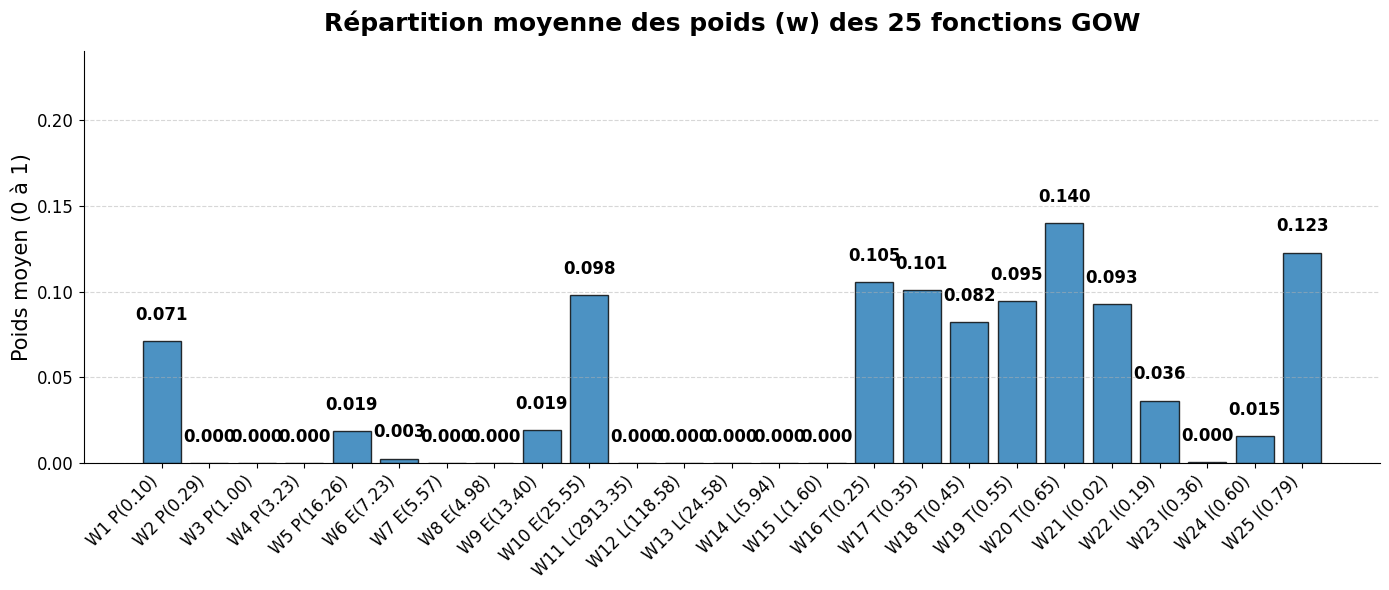

[7.10034221e-02 0.00000000e+00 0.00000000e+00 0.00000000e+00
 1.87952463e-02 2.50661398e-03 6.77576408e-06 0.00000000e+00
 1.89477010e-02 9.80962006e-02 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 1.05428491e-01
 1.00661322e-01 8.22478407e-02 9.46552925e-02 1.40171830e-01
 9.25901691e-02 3.63518601e-02 3.30527862e-04 1.54984945e-02
 1.22708212e-01]


In [ ]:
import matplotlib.pyplot as plt


TITLE_FS  = 18   # titre         
LABEL_FS  = 15   # label y       
TICK_FS   = 12   # graduations x  
ANNOT_FS  = 12   # valeurs au-dessus des barres 

plt.figure(figsize=(14, 6))

# Création des barres
bars = plt.bar(labels_actifs, poids_moyens, color='tab:blue', edgecolor='black', alpha=0.8)

# Ajout des valeurs au-dessus
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2, yval + 0.01,
        f'{yval:.3f}',
        ha='center', va='bottom', fontsize=ANNOT_FS, fontweight='bold' 
    )

# Esthétique
plt.title(
    f'Répartition moyenne des poids (w) des {num_fonctions} fonctions GOW',
    fontsize=TITLE_FS, fontweight='bold', pad=15                   
)
plt.ylabel('Poids moyen (0 à 1)', fontsize=LABEL_FS)                 
plt.ylim(0, max(poids_moyens) + 0.1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right', fontsize=TICK_FS)                
plt.tick_params(axis='y', labelsize=TICK_FS)                       

# Nettoyage des bordures
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(poids_moyens)